In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [4]:
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
data.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [8]:
data["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

C:\Users\telso\AppData\Local\Temp\ipykernel_46676\2593034897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


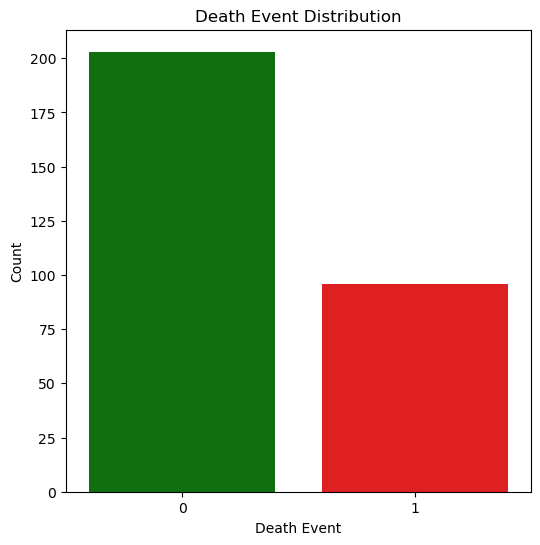

In [10]:
plt.figure(figsize=(6,6))

sns.countplot(
    x="DEATH_EVENT",
    data=data,
    palette=["green","red"]
)

plt.title("Death Event Distribution")
plt.xlabel("Death Event")
plt.ylabel("Count")

plt.show()

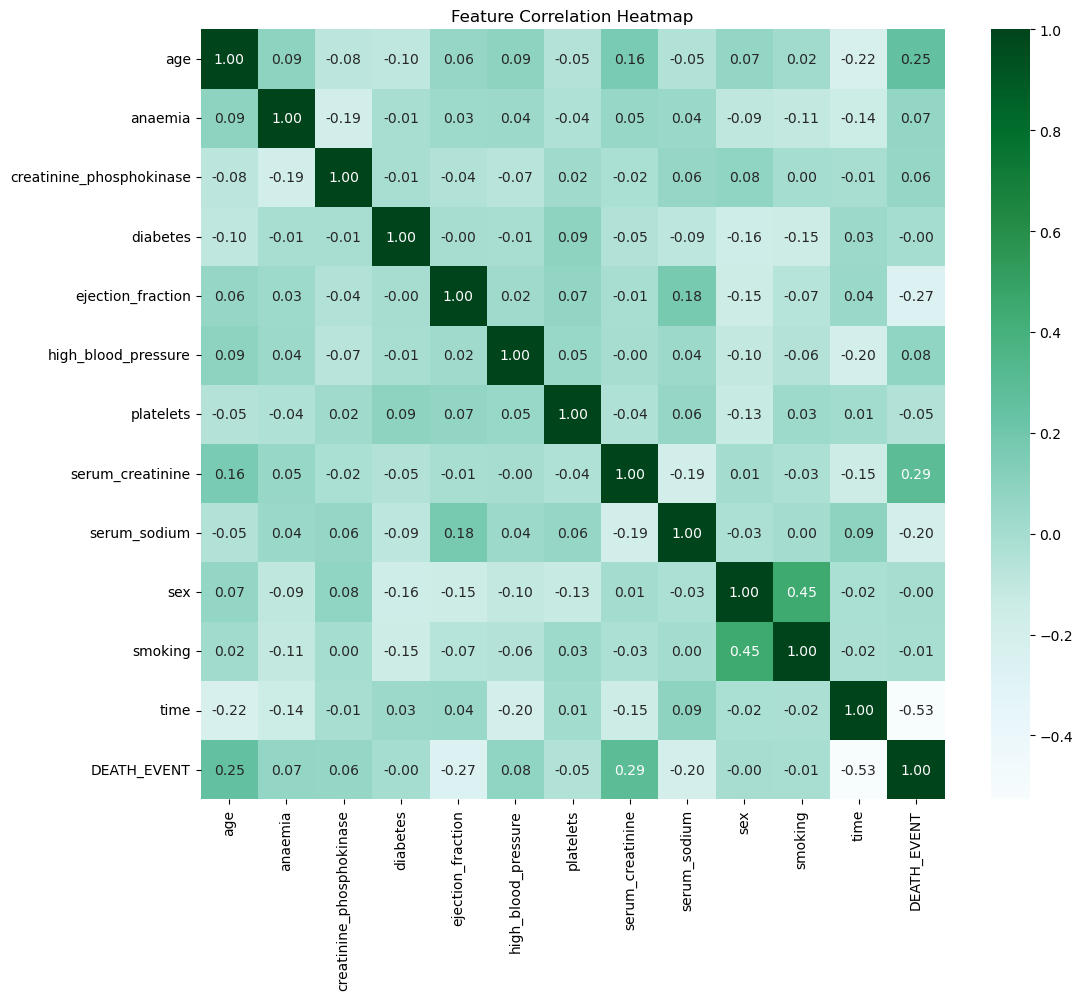

In [11]:
plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="BuGn",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

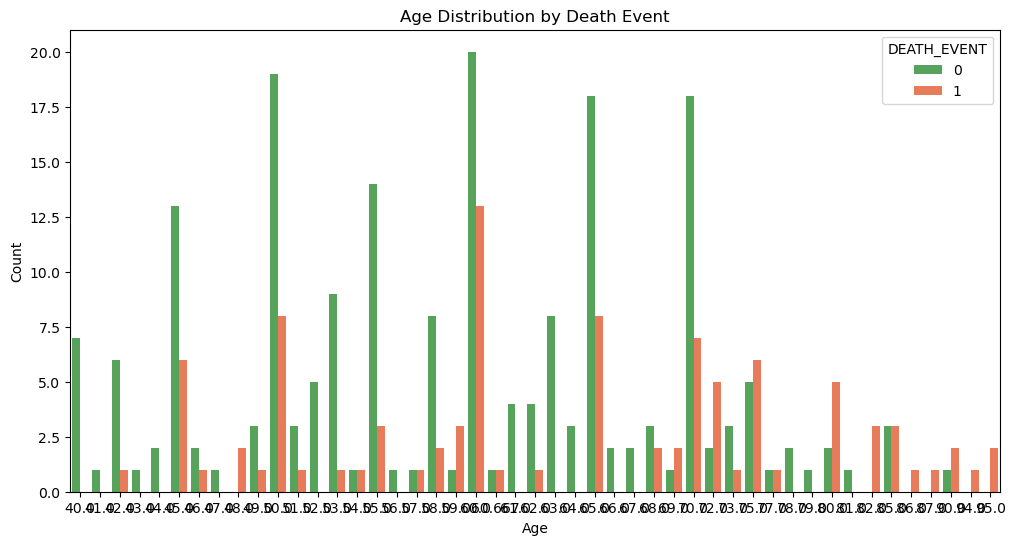

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="age",
    data=data,
    hue="DEATH_EVENT",
    palette=["#4CAF50", "#FF7043"]   # green-orange colors
)

plt.title("Age Distribution by Death Event")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

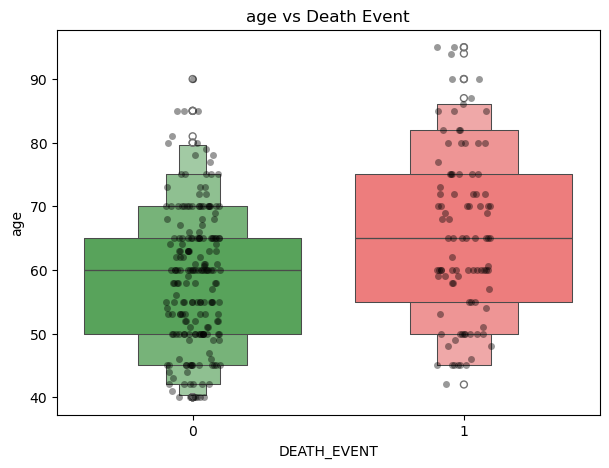

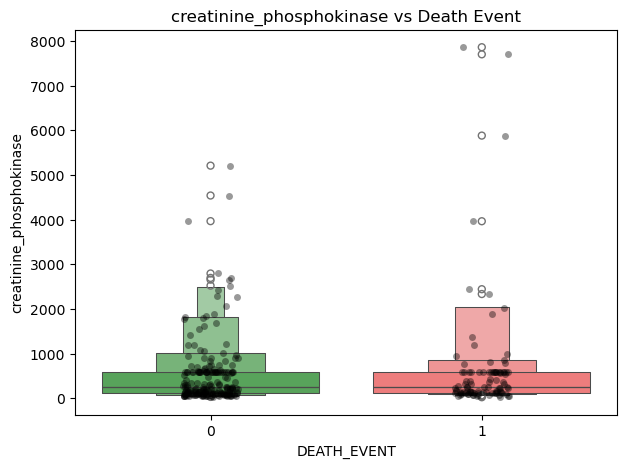

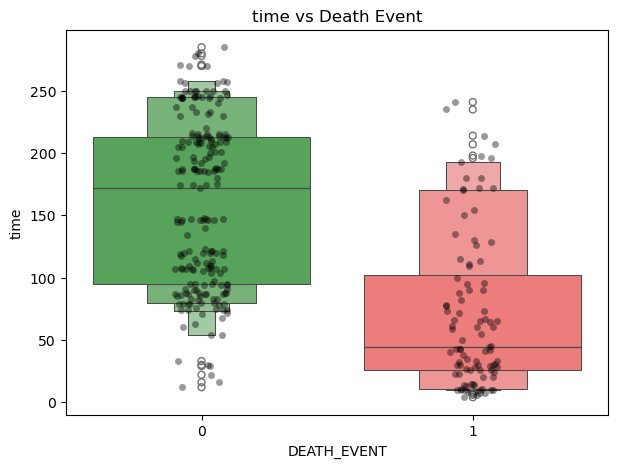

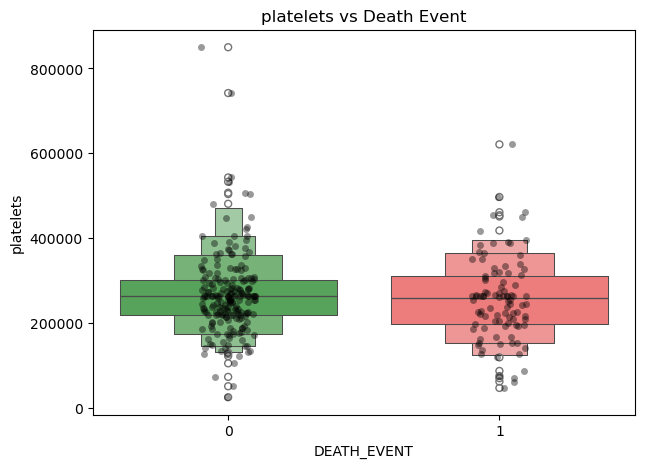

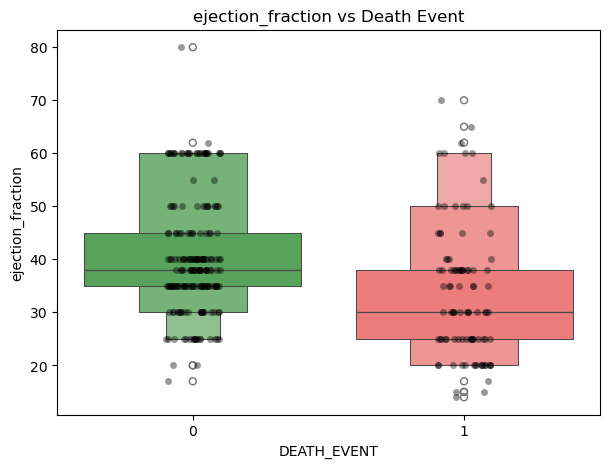

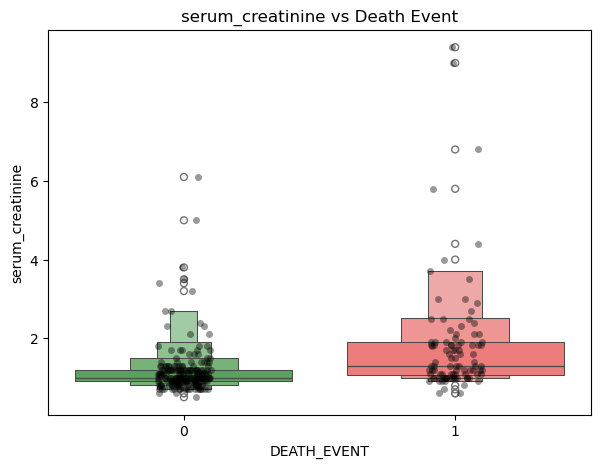

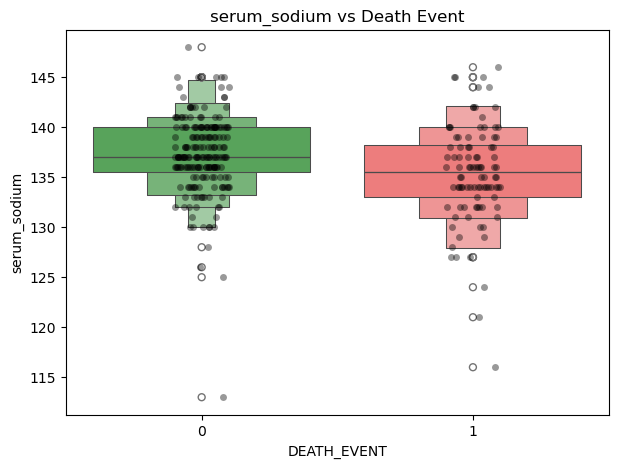

In [15]:
features = [
    "age",
    "creatinine_phosphokinase",
    "time",
    "platelets",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium"
]

for feature in features:

    plt.figure(figsize=(7,5))

    sns.boxenplot(
        x="DEATH_EVENT",
        y=feature,
        hue="DEATH_EVENT",
        data=data,
        palette=["#4CAF50","#FF6B6B"],
        legend=False
    )

    sns.stripplot(
        x="DEATH_EVENT",
        y=feature,
        data=data,
        color="black",
        alpha=0.4,
        jitter=True
    )

    plt.title(f"{feature} vs Death Event")
    plt.show()

In [18]:
# ==============================
# Feature Scaling
# ==============================

from sklearn.preprocessing import StandardScaler

X = data.drop(["DEATH_EVENT"], axis=1)
y = data["DEATH_EVENT"]

sc = StandardScaler()
X_sc = sc.fit_transform(X)

cols = list(X.columns)

X_sc = pd.DataFrame(X_sc, columns=cols)

# Describe scaled dataset
X_sc.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


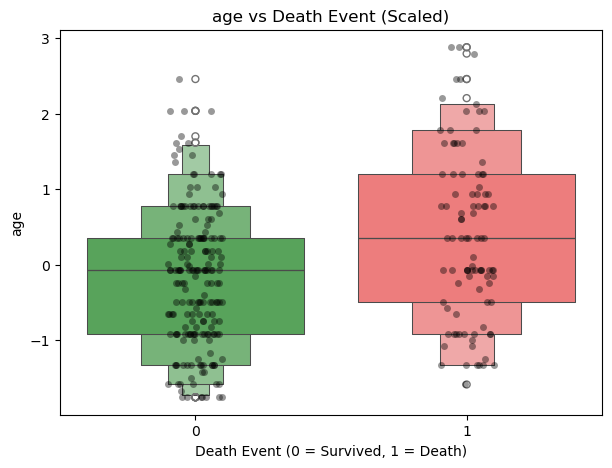

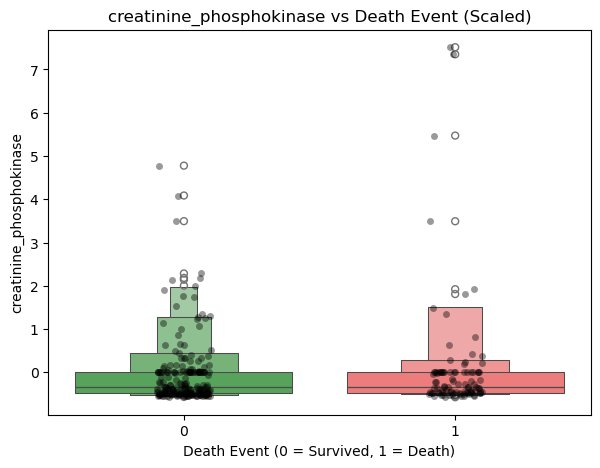

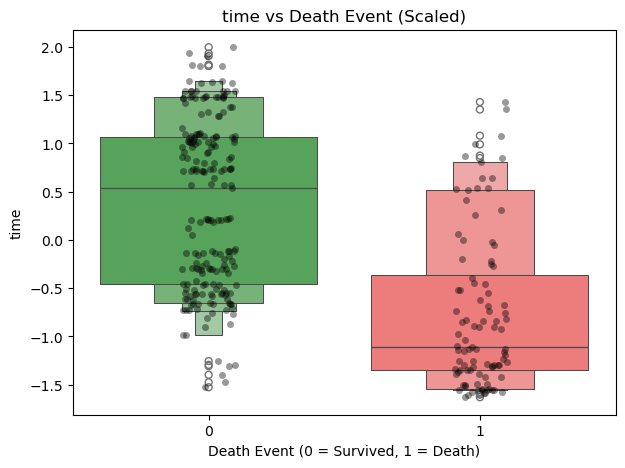

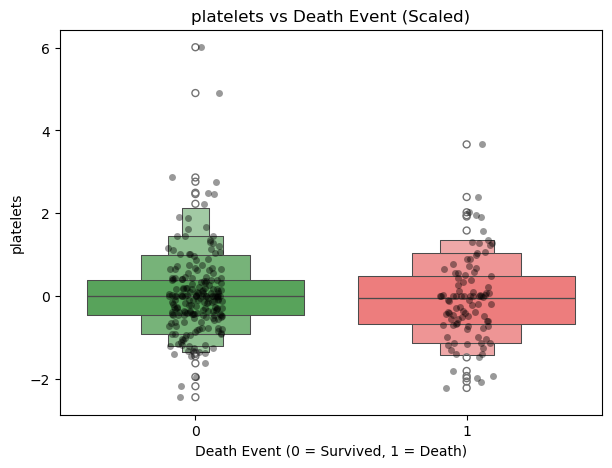

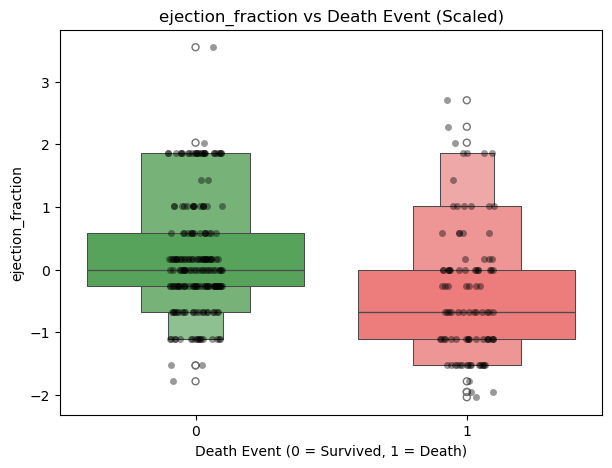

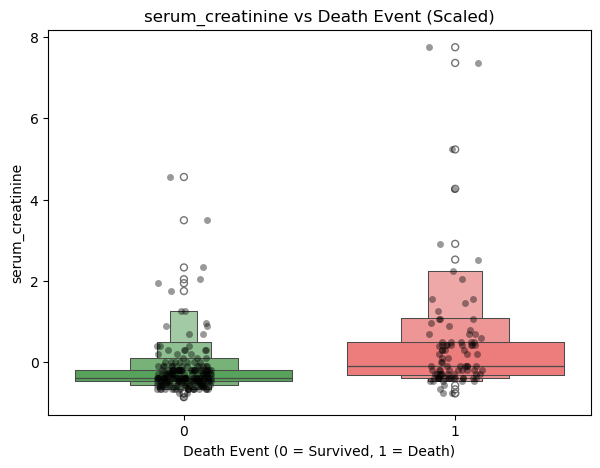

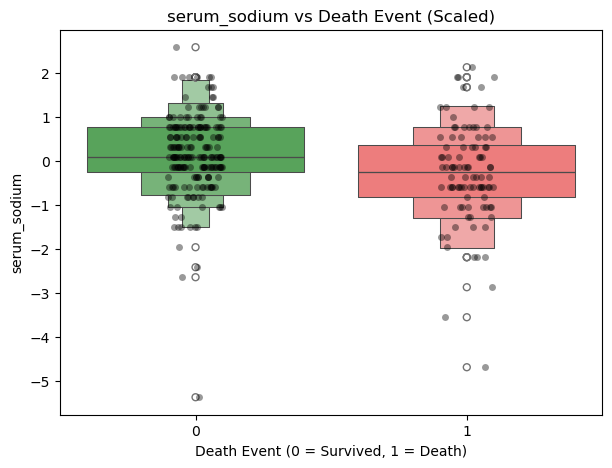

In [19]:
# Combine scaled data with target
scaled_data = X_sc.copy()
scaled_data["DEATH_EVENT"] = y


features = [
    "age",
    "creatinine_phosphokinase",
    "time",
    "platelets",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium"
]

for feature in features:

    plt.figure(figsize=(7,5))

    sns.boxenplot(
        x="DEATH_EVENT",
        y=feature,
        hue="DEATH_EVENT",
        data=scaled_data,
        palette=["#4CAF50", "#FF6B6B"],
        legend=False
    )

    sns.stripplot(
        x="DEATH_EVENT",
        y=feature,
        data=scaled_data,
        color="black",
        alpha=0.4,
        jitter=True
    )

    plt.title(f"{feature} vs Death Event (Scaled)")
    plt.xlabel("Death Event (0 = Survived, 1 = Death)")
    plt.ylabel(feature)

    plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sc,     # scaled features
    y,        # target
    test_size=0.3,
    random_state=42
)

In [22]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ======================
# SVM Model
# ======================

model1 = SVC()

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))


# ======================
# Logistic Regression
# ======================

model2 = LogisticRegression()

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred2))

SVM Accuracy: 0.7666666666666667
Logistic Regression Accuracy: 0.7888888888888889


In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = SVC()

accuracies = []

for train_index, test_index in skf.split(X_sc, y):

    X_train, X_test = X_sc.iloc[train_index], X_sc.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

print("Fold accuracies:", accuracies)
print("Mean accuracy:", np.mean(accuracies))

Fold accuracies: [0.7666666666666667, 0.8333333333333334, 0.8166666666666667, 0.85, 0.7796610169491526]
Mean accuracy: 0.8092655367231639


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sc,
    y,
    test_size=0.3,
    random_state=42
)

In [25]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks

In [26]:
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,
    patience=20,
    restore_best_weights=True
)

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(12,)))
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))